# 🧾 Análisis de Datos de Contratación Pública - SECOP II

**Finalidad**: Este notebook tiene como objetivo demostrar un proceso completo de extracción, transformación, análisis exploratorio y consulta de datos desde el portal público de contratación de Colombia (SECOP II), utilizando PySpark y SQL. Este documento es material de referencia para estudiantes, investigadores y profesionales de ingeniería de datos.

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, isnan, when, count, year, month, to_date
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import requests

spark = SparkSession.builder \
    .appName("SECOP_ETL") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .enableHiveSupport() \
    .config("spark.sql.catalogImplementation", "hive") \
    .config("spark.hadoop.fs.defaultFS", "hdfs://namenode:9000") \
    .enableHiveSupport() \
    .getOrCreate()

## 📥 Capítulo 1: Extracción de Datos desde API SECOP II

In [2]:
# URL base de la API SECOP II
BASE_URL = "https://www.datos.gov.co/resource/jbjy-vk9h.json"
LIMIT = 5000  # Máximo por página
offset = 0
data = []
Total_LIMIT=20000 # Máximo numero de registro a traer
i=0
while True:
    url = f"{BASE_URL}?$limit={LIMIT}&$offset={offset}"
    print(f"Descargando {LIMIT} registros desde offset={offset}...")
    response = requests.get(url)

    if response.status_code != 200:
        print(f"Error {response.status_code}: {response.text}")
        break

    batch = response.json()
    if not batch:
        break

    data.extend(batch)
    offset += LIMIT
    i=i+LIMIT
    if i>=Total_LIMIT:
        break
print(f"Total registros descargados: {len(data)}")

Descargando 5000 registros desde offset=0...
Descargando 5000 registros desde offset=5000...
Descargando 5000 registros desde offset=10000...
Descargando 5000 registros desde offset=15000...
Total registros descargados: 20000


Convertimos el JSON en **DataFrame Pandas**, realizamos limpieza básica y luego lo pasamos a Spark.

In [3]:
# Convertir JSON -> Pandas DataFrame
df_pandas = pd.DataFrame(data)
print(f"Columnas originales: {len(df_pandas.columns)}")
df_pandas.head()

Columnas originales: 87


,nombre_entidad,nit_entidad,departamento,ciudad,localizaci_n,orden,sector,rama,entidad_centralizada,proceso_de_compra,...,tipo_de_documento_supervisor,n_mero_de_documento_supervisor,nombre_ordenador_de_pago,tipo_de_documento_ordenador_de_pago,n_mero_de_documento_ordenador_de_pago,ultima_actualizacion,fecha_inicio_liquidacion,fecha_fin_liquidacion,fecha_de_inicio_de_ejecucion,fecha_de_fin_de_ejecucion
0,SUBRED INTEGRADA DE SERVICIO DE SALUD CENTRO O...,900959051,Distrito Capital de Bogotá,No Definido,"Colombia, Bogotá, No Definido",Territorial,Salud y Protección Social,Ejecutivo,Descentralizada,CO1.BDOS.2218096,...,Cédula de Ciudadanía,23556631,No definido,No definido,No definido,NaN,NaN,NaN,NaN,NaN
1,GOBERNACION DEL HUILA*,800103913,Huila,No Definido,"Colombia, Huila , No Definido",Territorial,Servicio Público,Ejecutivo,Centralizada,CO1.BDOS.5736116,...,No definido,No definido,No definido,No definido,No definido,NaN,NaN,NaN,NaN,NaN
2,SUBRED INTEGRADA DE SERVICIOS DE SALUD SUR OCC...,900959048,Distrito Capital de Bogotá,No Definido,"Colombia, Bogotá, No Definido",Territorial,Salud y Protección Social,Ejecutivo,Descentralizada,CO1.BDOS.1661748,...,No definido,No definido,No definido,No definido,No definido,2022-05-23T00:00:00.000,NaN,NaN,NaN,NaN
3,MUNICIPIO DE DAGUA,800100514,Valle del Cauca,Dagua,"Colombia, Valle del Cauca , Dagua",Territorial,No aplica/No pertenece,Ejecutivo,Descentralizada,CO1.BDOS.3221414,...,Cédula de Ciudadanía,14838687,No definido,No definido,No definido,2022-12-07T00:00:00.000,NaN,NaN,NaN,NaN
4,CUNDINAMARCA-ALCALDIA MUNICIPIO MOSQUERA,899999342,Cundinamarca,Mosquera,"Colombia, Cundinamarca , Mosquera",Territorial,No aplica/No pertenece,Ejecutivo,Descentralizada,CO1.BDOS.7671753,...,Cédula de Ciudadanía,1026277899,No definido,No definido,No definido,2025-03-20T00:00:00.000,NaN,NaN,NaN,NaN


In [4]:
# Convertir Pandas -> Spark DataFrame
df_raw = spark.createDataFrame(df_pandas)
df_raw.printSchema()
df_raw.show(5)

root
 |-- nombre_entidad: string (nullable = true)
 |-- nit_entidad: string (nullable = true)
 |-- departamento: string (nullable = true)
 |-- ciudad: string (nullable = true)
 |-- localizaci_n: string (nullable = true)
 |-- orden: string (nullable = true)
 |-- sector: string (nullable = true)
 |-- rama: string (nullable = true)
 |-- entidad_centralizada: string (nullable = true)
 |-- proceso_de_compra: string (nullable = true)
 |-- id_contrato: string (nullable = true)
 |-- referencia_del_contrato: string (nullable = true)
 |-- estado_contrato: string (nullable = true)
 |-- codigo_de_categoria_principal: string (nullable = true)
 |-- descripcion_del_proceso: string (nullable = true)
 |-- tipo_de_contrato: string (nullable = true)
 |-- modalidad_de_contratacion: string (nullable = true)
 |-- justificacion_modalidad_de: string (nullable = true)
 |-- fecha_de_firma: string (nullable = true)
 |-- fecha_de_inicio_del_contrato: string (nullable = true)
 |-- fecha_de_fin_del_contrato: string

## 🧹 Capítulo 2: Limpieza de Datos Nulos y Tipos

In [5]:
from pyspark.sql.functions import explode, col

# Paso 1: Explota el campo map `urlproceso` para convertir cada entrada key-value en una fila
df_flat = df_raw.selectExpr("*", "explode(urlproceso) as (urlproceso_key, urlproceso_value)") \
                .drop("urlproceso")

df_flat.printSchema()

root
 |-- nombre_entidad: string (nullable = true)
 |-- nit_entidad: string (nullable = true)
 |-- departamento: string (nullable = true)
 |-- ciudad: string (nullable = true)
 |-- localizaci_n: string (nullable = true)
 |-- orden: string (nullable = true)
 |-- sector: string (nullable = true)
 |-- rama: string (nullable = true)
 |-- entidad_centralizada: string (nullable = true)
 |-- proceso_de_compra: string (nullable = true)
 |-- id_contrato: string (nullable = true)
 |-- referencia_del_contrato: string (nullable = true)
 |-- estado_contrato: string (nullable = true)
 |-- codigo_de_categoria_principal: string (nullable = true)
 |-- descripcion_del_proceso: string (nullable = true)
 |-- tipo_de_contrato: string (nullable = true)
 |-- modalidad_de_contratacion: string (nullable = true)
 |-- justificacion_modalidad_de: string (nullable = true)
 |-- fecha_de_firma: string (nullable = true)
 |-- fecha_de_inicio_del_contrato: string (nullable = true)
 |-- fecha_de_fin_del_contrato: string

In [6]:
# Conteo de nulos por columna
df_flat.select([count(when(col(c).isNull() | isnan(c), c)).alias(c) for c in df_flat.columns]).show()

# Selección y conversión de columnas clave
df = df_flat.select(
    col("id_contrato").alias("idcontrato"),
    col("estado_contrato"),
    col("modalidad_de_contratacion").alias("modalidad_contratacion"),
    to_date("fecha_de_firma").alias("fecha_firma"),
    col("valor_del_contrato").cast("double").alias("valor_contrato")
).na.drop(subset=["idcontrato", "valor_contrato", "fecha_firma"])

+--------------+-----------+------------+------+------------+-----+------+----+--------------------+-----------------+-----------+-----------------------+---------------+-----------------------------+-----------------------+----------------+-------------------------+--------------------------+--------------+----------------------------+-------------------------+----------------------+----------------+-------------------+--------------------+--------+-------+------------------------+-----------+--------------------+------------------------+---------+----------------------+-------------+------------------+------------------------+---------------+-----------------------+------------+----------------+------------------+----------------------------+-----------+-----------+---------+---------+--------------+---------------+----------------+------------------+-------------------+--------------------------+--------------------------------+-----------------------------+-------------------------

## 📊 Capítulo 3: Análisis Exploratorio de Datos (EDA)

In [7]:
df.printSchema()

root
 |-- idcontrato: string (nullable = true)
 |-- estado_contrato: string (nullable = true)
 |-- modalidad_contratacion: string (nullable = true)
 |-- fecha_firma: date (nullable = true)
 |-- valor_contrato: double (nullable = true)



In [8]:
from pyspark.sql.functions import year, sum as _sum, count
# Análisis básico
df.groupBy("estado_contrato").count().show()
df.groupBy("modalidad_contratacion").count().show(truncate=False)

# Agregación por año
df.withColumn("año", year("fecha_firma")) \
  .groupBy("año") \
  .agg(   _sum("valor_contrato").alias("total_valor_contrato"),
          count("idcontrato").alias("cantidad_contratos"),
          )\
  .orderBy("año") \
  .show()

+---------------+-----+
|estado_contrato|count|
+---------------+-----+
|     Suspendido|   15|
|      terminado| 2608|
|        Cerrado| 5158|
|         cedido|  104|
|     Modificado| 3521|
|   En ejecución| 6275|
|         Activo|  842|
|     Prorrogado|    1|
+---------------+-----+

+-----------------------------------------------------------+-----+
|modalidad_contratacion                                     |count|
+-----------------------------------------------------------+-----+
|Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes|4    |
|Contratación régimen especial                              |2386 |
|Contratación régimen especial (con ofertas)                |135  |
|Selección Abreviada de Menor Cuantía                       |212  |
|Contratación Directa (con ofertas)                         |294  |
|Selección abreviada subasta inversa                        |177  |
|Concurso de méritos abierto                                |47   |
|Licitación pública            

## 🔧 Capítulo 4: Transformación y Subconjuntos de Datos

In [9]:
# Tabla 1: Contratos por encima de 1.000 millones
df_mayor = df.filter(col("valor_contrato") > 1_000_000_000)
df_mayor.createOrReplaceTempView("contratos_mayores")

# Tabla 2: Contratos en modalidad 'Contratación Directa'
df_directa = df.filter(col("modalidad_contratacion") == "Contratación Directa (con ofertas)")
df_directa.createOrReplaceTempView("contratos_directos")

## 💬 Capítulo 5: Consultas SQL sobre las Tablas Resultantes

In [10]:
spark.sql("SELECT COUNT(*) as total FROM contratos_mayores").show()
spark.sql("SELECT year(fecha_firma) as anio, COUNT(*) total FROM contratos_directos GROUP BY 1 ORDER BY 1").show()

+-----+
|total|
+-----+
|  305|
+-----+

+----+-----+
|anio|total|
+----+-----+
|2016|    2|
|2017|   70|
|2018|   20|
|2019|    5|
|2020|   17|
|2021|   29|
|2022|   31|
|2023|   44|
|2024|   43|
|2025|   33|
+----+-----+



## 💾 Capítulo 6: Persistencia de Datos
En esta sección guardamos los datos transformados en formato **Parquet** y **Hive** para su posterior consulta y análisis.

### 1. Persistir DataFrame en formato Parquet
El formato **Parquet** es eficiente, columnar y está optimizado para Spark.

In [11]:
# Ruta donde se almacenará el archivo parquet
output_path = "hdfs://namenode:9000/user/jovyan/secop_cleaned"

# Guardar DataFrame limpio
df_flat.write \
    .mode("overwrite") \
    .parquet(output_path)

print(f"✅ Datos persistidos en: {output_path}")

✅ Datos persistidos en: hdfs://namenode:9000/user/jovyan/secop_cleaned


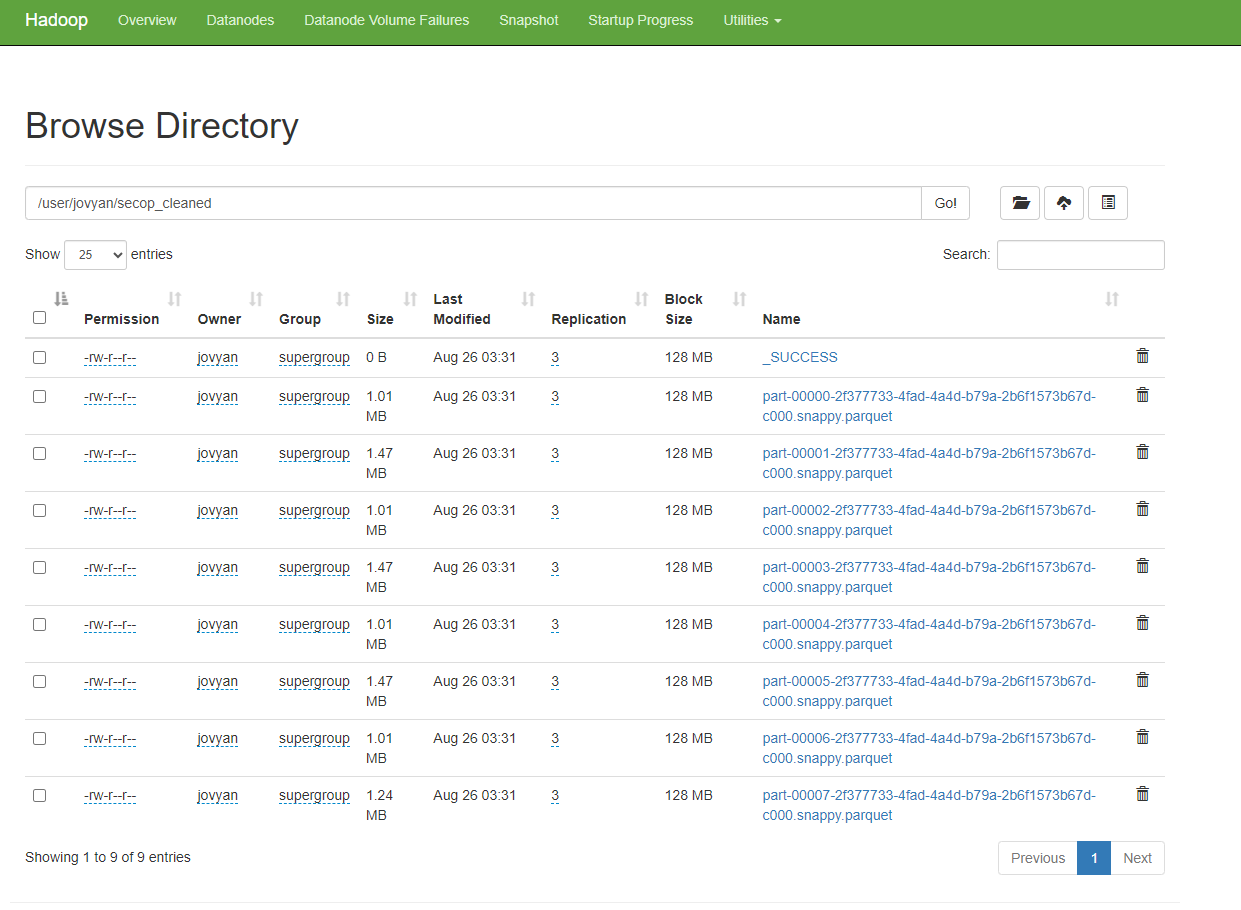

### 2. Persistir DataFrame como tabla gestionada por Hive

Si quieres que los datos estén disponibles directamente para **consultas SQL** desde Spark o Hive, primero habilitamos soporte Hive:

In [12]:
spark = SparkSession.builder \
    .appName("Persistencia_SECOP") \
    .config("spark.sql.catalogImplementation", "hive") \
    .enableHiveSupport() \
    .getOrCreate()

In [13]:
# Crear la base de datos si no existe
spark.sql("CREATE DATABASE IF NOT EXISTS secop")

# Seleccionar la base de datos
spark.catalog.setCurrentDatabase("secop")

In [14]:
# Guardar como tabla Hive
df_flat.write \
    .mode("overwrite") \
    .saveAsTable("secop.secop_contratos_limpios")

print("✅ Tabla Hive creada: secop.secop_contratos_limpios")

✅ Tabla Hive creada: secop.secop_contratos_limpios


In [15]:
#Prueba de la persistecia de la tabla en el esquema secop
spark.sql("SELECT nombre_entidad,nit_entidad,departamento,ciudad,localizaci_n,orden,sector,rama,entidad_centralizada,proceso_de_compra,id_contrato FROM secop.secop_contratos_limpios LIMIT 5").show()

+--------------------+-----------+--------------------+-------------+--------------------+-----------+--------------------+---------+--------------------+-----------------+------------------+
|      nombre_entidad|nit_entidad|        departamento|       ciudad|        localizaci_n|      orden|              sector|     rama|entidad_centralizada|proceso_de_compra|       id_contrato|
+--------------------+-----------+--------------------+-------------+--------------------+-----------+--------------------+---------+--------------------+-----------------+------------------+
|UNIDAD ADMINISTRA...|  900498879|Distrito Capital ...|       Bogotá|Colombia, Bogotá,...|   Nacional|Inclusión Social ...|Ejecutivo|        Centralizada|  CO1.BDOS.678085| CO1.PCCNTR.741447|
|ALCALDIA MUNICIPI...|  890982489|           Antioquia|  No Definido|Colombia,  Antioq...|Territorial|    Servicio Público|Ejecutivo|     Descentralizada| CO1.BDOS.3038563|CO1.PCCNTR.3933310|
|ALCALDIA DE FLORI...|  890205176|      

### 3. Validar datos persistidos

Para confirmar que los datos están almacenados correctamente:

In [16]:
df_check = spark.read.parquet(output_path)
df_check.select("nombre_entidad","nit_entidad").show(truncate=False)

# Si guardaste en Hive, consulta con SQL directamente
spark.sql("SELECT nombre_entidad,nit_entidad FROM secop.secop_contratos_limpios LIMIT 5").show(truncate=False)

+-------------------------------------------------------------------------------------------+-----------+
|nombre_entidad                                                                             |nit_entidad|
+-------------------------------------------------------------------------------------------+-----------+
|UNIDAD ADMINISTRATIVA ESPECIAL DE GESTION DE RESTITUCION DE TIERRAS DESPOJADAS**           |900498879  |
|ALCALDIA MUNICIPIO DE ANORI                                                                |890982489  |
|ALCALDIA DE FLORIDABLANCA                                                                  |890205176  |
|SENA REGIONAL RISARALDA Grupo de Apoyo Administrativo Mixto//                              |899999034  |
|MINVIVIENDA                                                                                |900463725  |
|E.S.E CLINICA MATERNIDAD RAFAEL CALVO C.                                                   |806001061  |
|IDRD - ENTIDAD OFICIAL.                      

### 4. Siguiente paso
Una vez persistidos los datos:

- Los archivos **Parquet** se pueden consumir desde cualquier notebook Spark.

- Las **tablas Hive** permiten ejecutar **consultas SQL interactivas** sobre los datos transformados.

- Podemos optimizar aún más usando **partitionBy("año")** para mejorar el rendimiento en consultas por año.

Por ejemplo:

In [17]:
df

DataFrame[idcontrato: string, estado_contrato: string, modalidad_contratacion: string, fecha_firma: date, valor_contrato: double]

In [18]:
df.withColumn("año", year("fecha_firma")).write \
    .mode("overwrite") \
    .partitionBy("año") \
    .parquet("hdfs://namenode:9000/user/jovyan/secop_cleaned_partitioned")

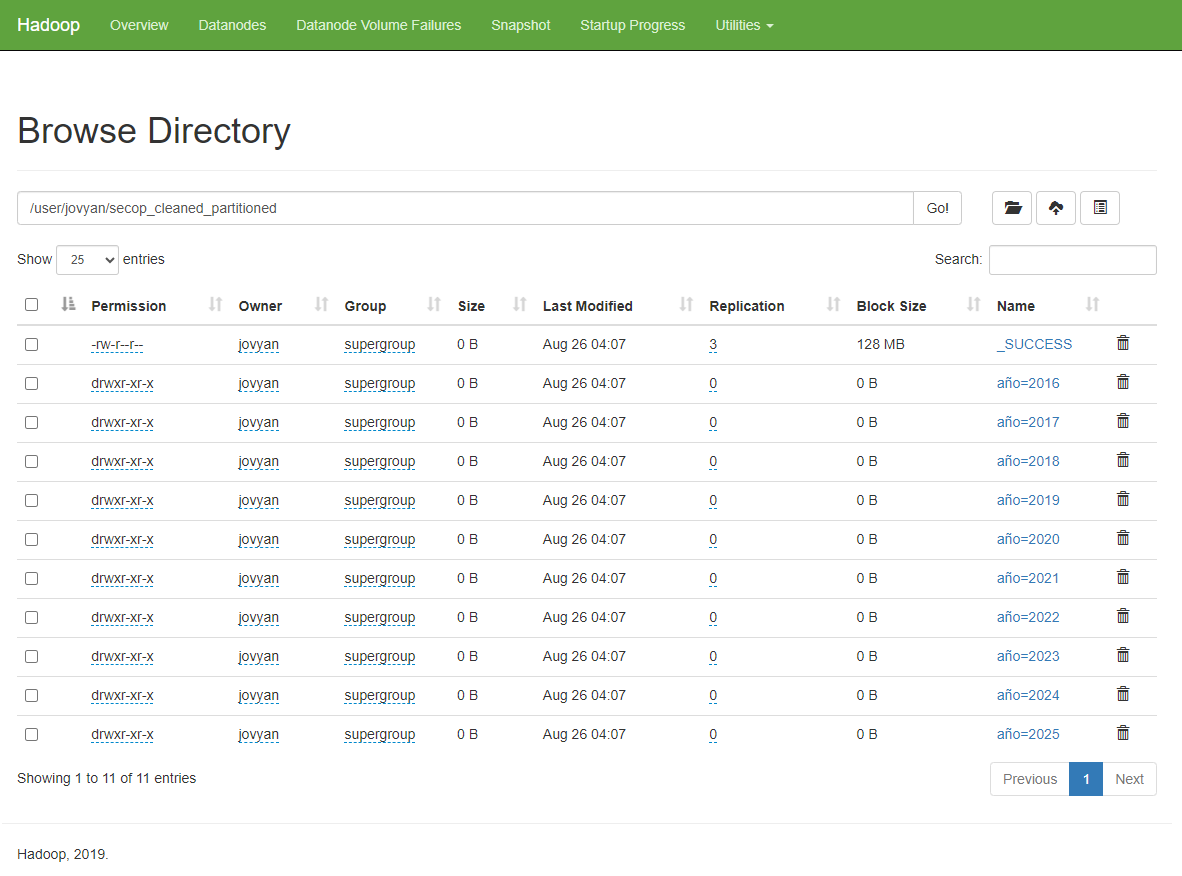

### Ayuda!

**1. Listar todas las bases de datos**

In [19]:
# Usando SQL
spark.sql("SHOW DATABASES").show(truncate=False)

# O usando el catálogo de Spark
spark.catalog.listDatabases()

+---------+
|namespace|
+---------+
|default  |
|secop    |
+---------+



[Database(name='default', catalog='spark_catalog', description='Default Hive database', locationUri='file:/home/jovyan/spark-warehouse'),
 Database(name='secop', catalog='spark_catalog', description='', locationUri='file:/home/jovyan/spark-warehouse/secop.db')]

**2. Seleccionar una base de datos**

Antes de ver las tablas, necesitas activar la base de datos sobre la que trabajarás:

In [20]:
spark.catalog.setCurrentDatabase("secop")

O también con SQL:

In [21]:
spark.sql("USE secop")

DataFrame[]

**3. Listar todas las tablas de la base de datos actual**

In [22]:
# Usando SQL
spark.sql("SHOW TABLES").show(truncate=False)

# O usando el catálogo de Spark
spark.catalog.listTables("secop")

+---------+-----------------------+-----------+
|namespace|tableName              |isTemporary|
+---------+-----------------------+-----------+
|secop    |secop_contratos_limpios|false      |
|         |contratos_directos     |true       |
|         |contratos_mayores      |true       |
+---------+-----------------------+-----------+



[Table(name='secop_contratos_limpios', catalog='spark_catalog', namespace=['secop'], description=None, tableType='MANAGED', isTemporary=False),
 Table(name='contratos_directos', catalog=None, namespace=[], description=None, tableType='TEMPORARY', isTemporary=True),
 Table(name='contratos_mayores', catalog=None, namespace=[], description=None, tableType='TEMPORARY', isTemporary=True)]

**4. Ver estructura de una tabla**

Para inspeccionar las columnas, tipos de datos y estructura de una tabla:

In [23]:
spark.sql("DESCRIBE secop.secop_contratos_limpios").show(truncate=False)

+-----------------------------+---------+-------+
|col_name                     |data_type|comment|
+-----------------------------+---------+-------+
|nombre_entidad               |string   |null   |
|nit_entidad                  |string   |null   |
|departamento                 |string   |null   |
|ciudad                       |string   |null   |
|localizaci_n                 |string   |null   |
|orden                        |string   |null   |
|sector                       |string   |null   |
|rama                         |string   |null   |
|entidad_centralizada         |string   |null   |
|proceso_de_compra            |string   |null   |
|id_contrato                  |string   |null   |
|referencia_del_contrato      |string   |null   |
|estado_contrato              |string   |null   |
|codigo_de_categoria_principal|string   |null   |
|descripcion_del_proceso      |string   |null   |
|tipo_de_contrato             |string   |null   |
|modalidad_de_contratacion    |string   |null   |


# 📌 Resumen de Comandos para Ver Bases de Datos y Tablas en Hive (PySpark)

A continuación, se resumen los comandos más importantes para **listar bases de datos, tablas** y **estructuras** en PySpark utilizando SQL y la API de Spark.

---

## Resumen

| **Acción**                | **Comando SQL**       | **API PySpark**                                     |
|--------------------------|-----------------------|-----------------------------------------------------|
| Ver bases de datos      | `SHOW DATABASES`      | `spark.catalog.listDatabases()`                     |
| Usar una base de datos  | `USE secop`          | `spark.catalog.setCurrentDatabase("secop")`         |
| Ver tablas             | `SHOW TABLES`       | `spark.catalog.listTables("secop")`                 |
| Ver estructura de tabla | `DESCRIBE tabla`   | `df.printSchema()`  o  `spark.sql("DESCRIBE tabla")` |


## 📌 Conclusiones
- Se logró conectar exitosamente con la API pública de SECOP II.
- Se implementó limpieza de datos nulos y transformación de tipos.
- Se aplicaron filtros para generar subconjuntos útiles (contratos altos y contratación directa).
- Se utilizó SQL sobre vistas temporales como ejemplo de explotación analítica.
- Este notebook puede servir como base para dashboards, alertas y analítica contractual avanzada.

## 📘 Capítulo 7: Lectura de Parquet y Tablas Hive con PySpark

## 1. Configurar la sesión de Spark con soporte Hive

Para poder leer tablas Hive, es necesario inicializar la sesión de Spark con el **Hive Warehouse Connector** habilitado.

```python
from pyspark.sql import SparkSession

# Crear la sesión de Spark con soporte para Hive
spark = SparkSession.builder \
    .appName("Lectura de Parquet y Tablas Hive") \
    .enableHiveSupport() \
    .getOrCreate()

print("✅ Sesión Spark inicializada con soporte Hive")


## 2. Lectura de archivos Parquet

Supongamos que tenemos los datos exportados en formato **Parquet** en la ruta:

`/user/data/secop/contratos.parquet`

```python
# Leer el archivo Parquet
df_parquet = spark.read.parquet("/user/data/secop/contratos.parquet")

# Mostrar esquema y primeras filas
df_parquet.printSchema()
df_parquet.show(5, tru
```

**Explicación:**

- Spark detecta automáticamente el esquema de los archivos Parquet.

- Se pueden leer múltiples archivos si la ruta corresponde a un directorio.ncate=False)


## 3. Lectura de tablas Hive

Para consultar las tablas **Hive** previamente creadas (por ejemplo, `secop_contratos_limpios`):

```python
# Listar bases de datos disponibles
spark.sql("SHOW DATABASES").show()

# Seleccionar la base de datos
spark.catalog.setCurrentDatabase("secop")

# Listar tablas en la base seleccionada
spark.sql("SHOW TABLES").show()

# Leer la tabla Hive en un DataFrame
df_hive = spark.table("secop_contratos_limpios")

# Ver estructura y datos
df_hive.printSchema()
df_hive.show(5, truncate=False)


## 4. Consultas SQL sobre la tabla Hive

Puedes ejecutar consultas **SQL** directamente sobre las tablas **Hive**:

```python
# Consultar contratos con valor mayor a 1,000,000,000
df_query = spark.sql("""
    SELECT idcontrato, estado_contrato, modalidad_contratacion, valor_contrato
    FROM secop_contratos_limpios
    WHERE valor_contrato > 1000000000

## 5. Unir datos Parquet y Hive (opcional)

Si deseas combinar datos leídos desde **Parquet** y desde **Hive**:

```python
df_union = df_parquet.unionByName(df_hive)

print("Número de filas combinadas:", df_union.count())
df_union.show(5)